# Stock Price Forecasting Notebook (Cleaned Final Version)

This notebook is the cleaned submission version. It fixes prior sentiment-scaler leakage, adds a consolidated model comparison table, includes directional accuracy, adds a naive baseline, validates zero-sentiment coverage, and removes stale or conflicting experimental cells.


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
%pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

data = {}
for sym in symbols:
    data[sym] = yf.download(
        sym,
        start="2019-04-10",
        auto_adjust=True,
        progress=False
    )

print(data["AAPL"].head())


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-04-10  47.848698  47.877321  47.266747  47.385999   86781200
2019-04-11  47.450394  47.939328  47.328758  47.903554   83603200
2019-04-12  47.431305  47.734206  46.796887  47.510012  111042800
2019-04-15  47.517166  47.665041  47.226191  47.362140   70146400
2019-04-16  47.521950  48.027577  47.357381  47.572037  102785600


In [3]:
for sym in symbols:
    df = data[sym].copy()
    df["returns"] = df["Close"].pct_change()
    data[sym] = df.dropna().copy()

In [4]:
for sym in symbols:
    df = data[sym].copy()
    df["target_eda_price_next"] = df["Close"].shift(-1)
    data[sym] = df.dropna().copy()


In [5]:
from sklearn.metrics import mean_absolute_error

for sym in symbols:
    df = data[sym].copy()
    mae = mean_absolute_error(df["target_eda_price_next"], df["Close"])
    print(f"{sym} baseline MAE:", round(mae, 3))

AAPL baseline MAE: 1.992
MSFT baseline MAE: 3.563
GOOGL baseline MAE: 1.847
AMZN baseline MAE: 2.331
NVDA baseline MAE: 1.244


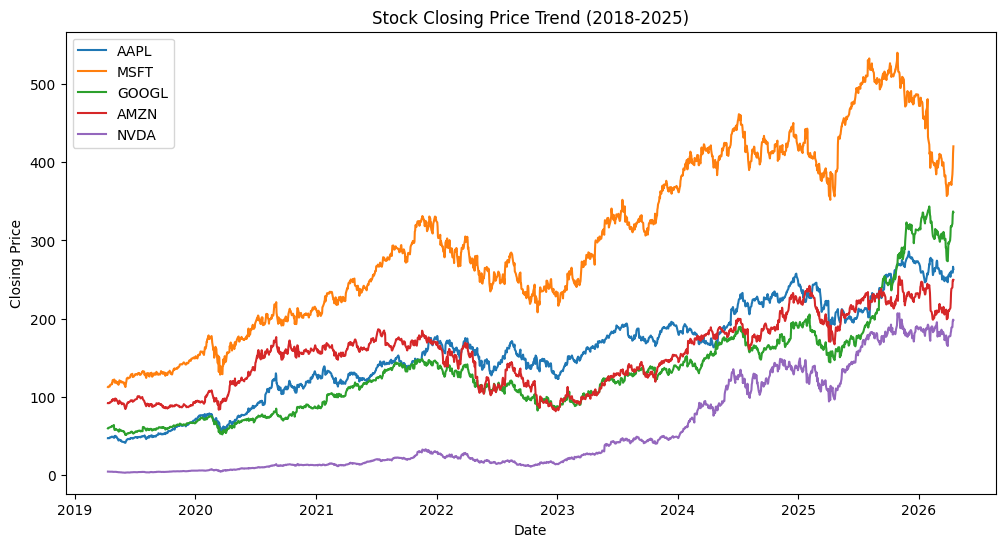

In [6]:
# Closing Price Trend (Time Series)

plt.figure(figsize=(12, 6))

for sym in symbols:
    plt.plot(data[sym].index, data[sym]["Close"], label=sym)

plt.title("Stock Closing Price Trend (2018-2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

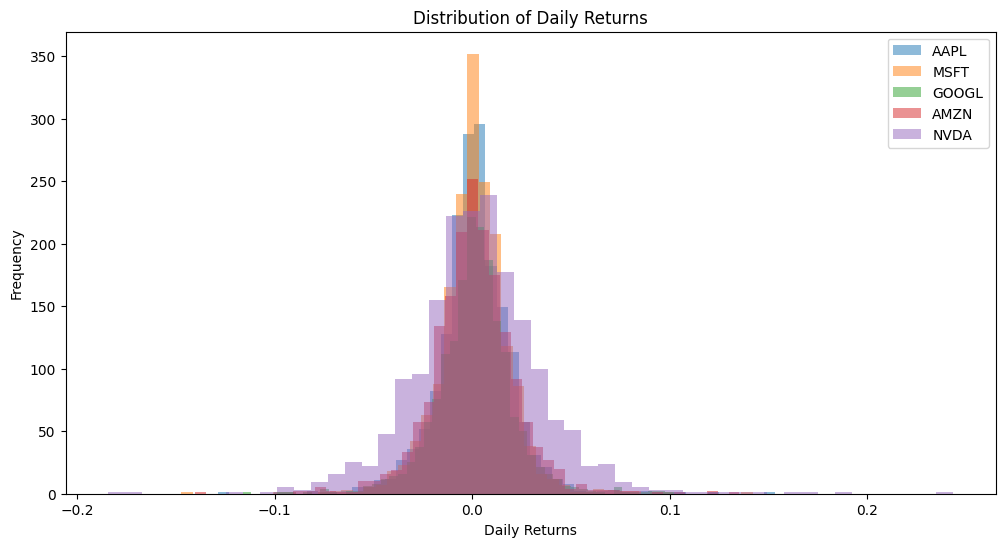

In [7]:
# Daily Returns Distribution (Risk Visualization)

plt.figure(figsize=(12, 6))

for sym in symbols:
    returns = data[sym]["returns"]
    plt.hist(returns.dropna(), bins=50, alpha=0.5, label=sym)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

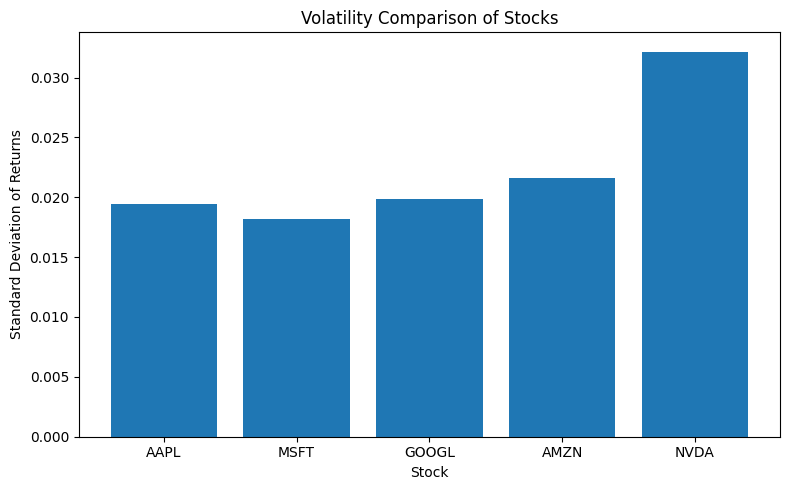

In [8]:
# Volatility Comparison (Bar Chart)

volatility = []

for sym in symbols:
    vol = data[sym]["returns"].std()
    volatility.append(vol)

vol_df = pd.DataFrame({
    "Stock": symbols,
    "Volatility": volatility
})

plt.figure(figsize=(8, 5))
plt.bar(vol_df["Stock"].values, vol_df["Volatility"].values)
plt.title("Volatility Comparison of Stocks")
plt.xlabel("Stock")
plt.ylabel("Standard Deviation of Returns")
plt.tight_layout()
plt.show()

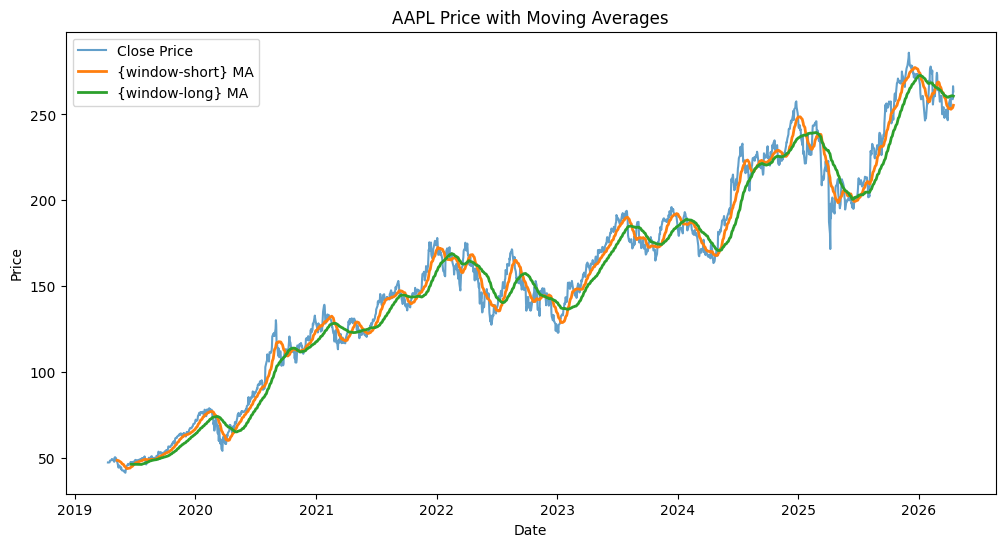

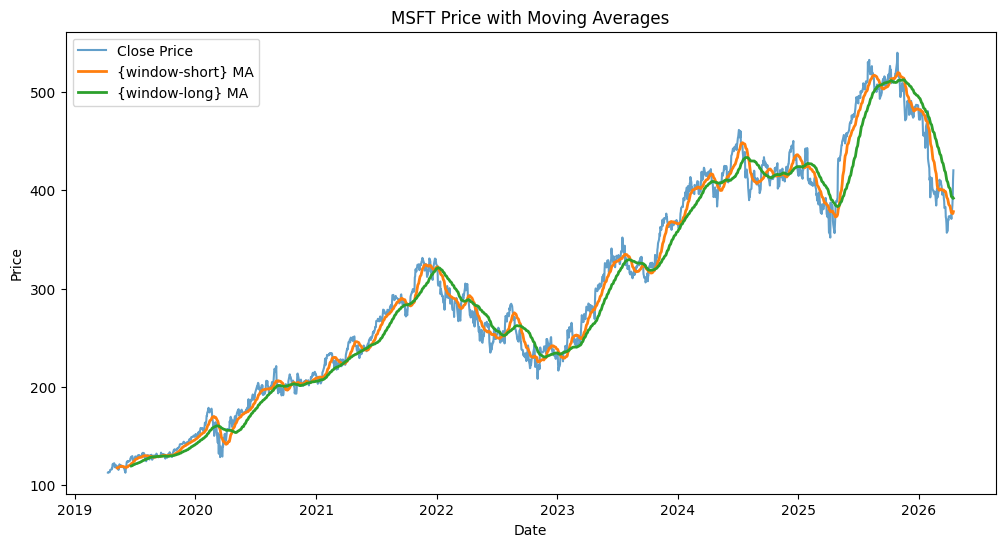

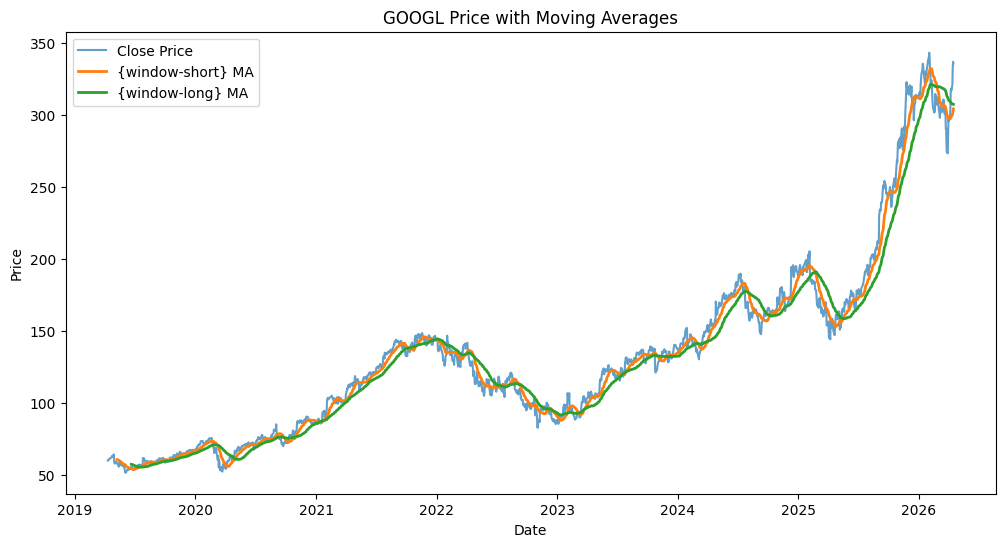

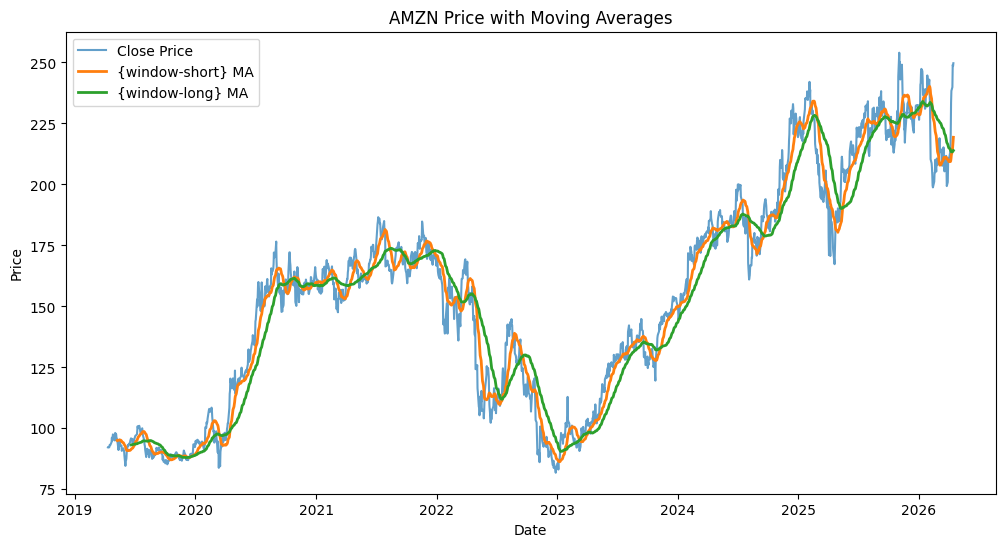

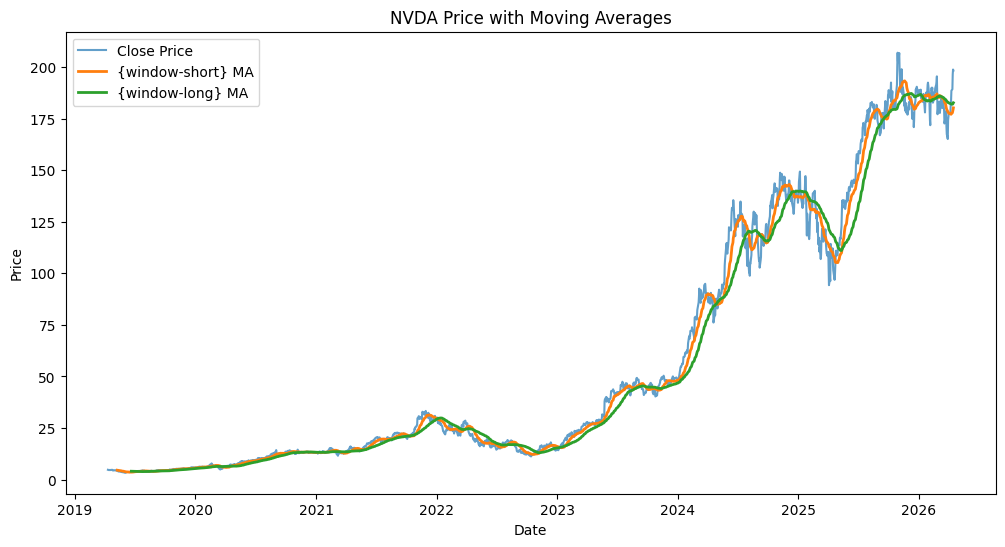

In [9]:
# Moving Averages (Trend Strength)

window_short = 20
window_long = 50

for sym in symbols:
    df = data[sym].copy()
    df["MA20"] = df["Close"].rolling(window_short).mean()
    df["MA50"] = df["Close"].rolling(window_long).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["Close"], label="Close Price", alpha=0.7)
    plt.plot(df.index, df["MA20"], label="{window-short} MA", linewidth=2)
    plt.plot(df.index, df["MA50"], label="{window-long} MA", linewidth=2)
    plt.title(f"{sym} Price with Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

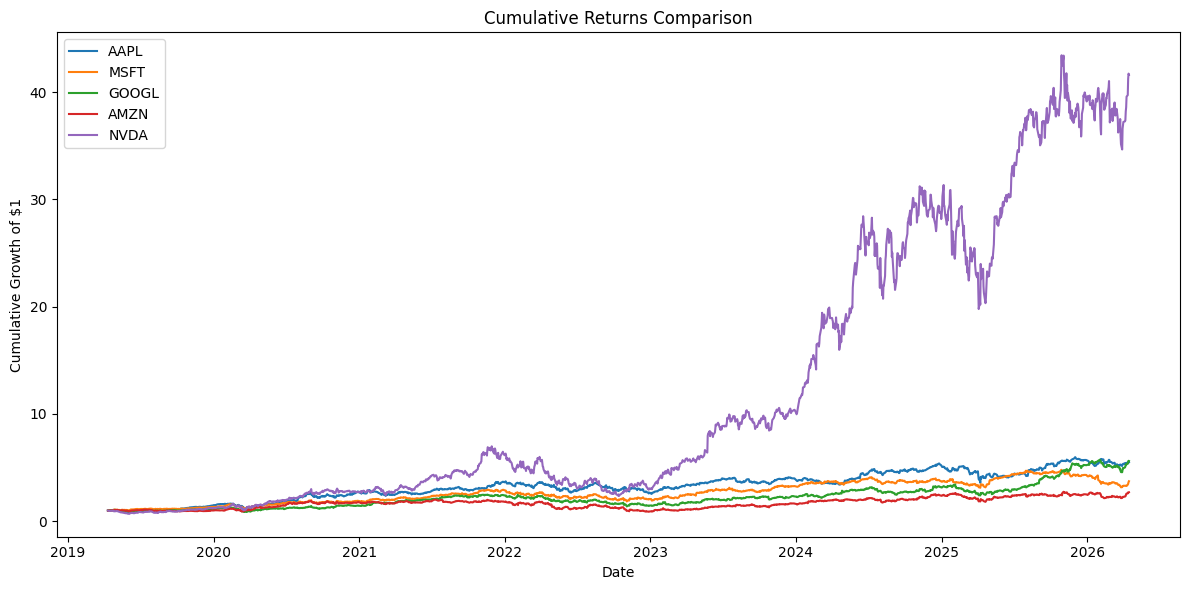

In [10]:
# Cumulative Returns (Performance Comparison)

plt.figure(figsize=(12, 6))

for sym in symbols:
    returns = data[sym]["returns"]
    cumulative_returns = (1 + returns).cumprod()
    plt.plot(cumulative_returns, label=sym)

plt.title("Cumulative Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import sys
!{sys.executable} -m pip install --upgrade protobuf


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
%%capture
%pip install tensorflow statsmodels
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.optimizers import Adam

In [13]:
def create_sequences(series, window_size=60):
    series = np.asarray(series)
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

def evaluate(true, pred):
    true = np. asarray(true).reshape(-1)
    pred = np. asarray(pred).reshape(-1)
    mae = mean_absolute_error(true, pred)
    rmse = math.sqrt(mean_squared_error(true, pred))
    # mape = np.mean(np.abs((true - pred) / true)) * 100 removed mape due to potential division by zero issues
    return mae, rmse

In [14]:
window_size = 60

for sym in symbols:
    print(f"\n===== {sym} Deep Learning Models =====")

    df = data[sym].copy()
    prices = df["Close"].values.reshape(-1, 1)

    train_end = int(len(prices) * 0.7)
    val_end = int(len(prices) * 0.85)
    train_prices= prices[:train_end]
    val_prices = prices[train_end - window_size:val_end]
    test_prices = prices[val_end - window_size:]

    # Scale
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_prices)
    val_scaled = scaler.transform(val_prices)
    test_scaled = scaler.transform(test_prices)

    # Create sequences & split
    X_train, y_train = create_sequences(train_scaled, window_size)
    X_val, y_val = create_sequences(val_scaled, window_size)
    X_test, y_test = create_sequences(test_scaled, window_size)
    
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
    # ---------------- LSTM ----------------
    lstm_model = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(50),
        Dense(1)
    ])

    lstm_model.compile(optimizer="adam", loss="mse")
    lstm_model.fit(X_train, y_train,
                   validation_data=(X_val, y_val),
                   epochs=30, batch_size=32,
                    callbacks=[early_stop], verbose=0)

    lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
    lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    lstm_mae, lstm_rmse = evaluate(y_test_actual, lstm_pred)

    print("LSTM Results:")
    print(f"MAE  : {lstm_mae:.3f}")
    print(f"RMSE : {lstm_rmse:.3f}")
    

    # ---------------- GRU ----------------
    gru_model = Sequential([
        Input(shape=(window_size, 1)),
        GRU(50),
        Dense(1) 
    ])

    gru_model.compile(optimizer="adam", loss="mse")
    gru_model.fit(X_train, y_train,
                   validation_data=(X_val, y_val),
                    epochs=30, batch_size=32,
                    callbacks=[early_stop], verbose=0)

    gru_pred_scaled = gru_model.predict(X_test, verbose=0)
    gru_pred = scaler.inverse_transform(gru_pred_scaled)

    gru_mae, gru_rmse = evaluate(y_test_actual, gru_pred)

    print("\nGRU Results:")
    print(f"MAE  : {gru_mae:.3f}")
    print(f"RMSE : {gru_rmse:.3f}")


===== AAPL Deep Learning Models =====
LSTM Results:
MAE  : 8.357
RMSE : 10.512

GRU Results:
MAE  : 4.781
RMSE : 6.243

===== MSFT Deep Learning Models =====
LSTM Results:
MAE  : 10.270
RMSE : 12.567

GRU Results:
MAE  : 6.090
RMSE : 8.411

===== GOOGL Deep Learning Models =====
LSTM Results:
MAE  : 27.760
RMSE : 35.541

GRU Results:
MAE  : 14.204
RMSE : 18.541

===== AMZN Deep Learning Models =====
LSTM Results:
MAE  : 4.677
RMSE : 6.173

GRU Results:
MAE  : 31.079
RMSE : 32.375

===== NVDA Deep Learning Models =====
LSTM Results:
MAE  : 16.175
RMSE : 18.111

GRU Results:
MAE  : 6.924
RMSE : 8.138


In [15]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning

arima_orders = [(1, 1, 0), (2, 1, 0), (3, 1, 0), (5, 1, 0), (2, 1, 2)]

warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

for sym in symbols:
    print(f"\n===== {sym} ARIMA Model =====")

    df = data[sym].copy()
    df.index = pd.DatetimeIndex(df.index)
    df = df.asfreq("B")
    prices = df["Close"].dropna()

    train_end = int(len(prices) * 0.7)
    val_end = int(len(prices) * 0.85)

    train = prices.iloc[:train_end]
    val = prices.iloc[train_end:val_end]
    test = prices.iloc[val_end:]

    best_order = None
    best_val_rmse = float("inf")

    for order in arima_orders:
        try:
            model = ARIMA(train, order=order)
            fitted = model.fit()
            val_forecast = fitted.forecast(steps=len(val))
            _, val_rmse = evaluate(val.values, val_forecast.values)

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_order = order
        except Exception:
            continue

    print(f"Best validation order: ARIMA{best_order}")
    print(f"Validation RMSE    : {best_val_rmse:.3f}")

    train_val = prices.iloc[:val_end]
    final_model = ARIMA(train_val, order=best_order)
    final_fitted = final_model.fit()

    test_forecast = final_fitted.forecast(steps=len(test))
    test_mae, test_rmse = evaluate(test.values, test_forecast.values)

    print("Final Test Results:")
    print(f"MAE  : {test_mae:.3f}")
    print(f"RMSE : {test_rmse:.3f}")


===== AAPL ARIMA Model =====
Best validation order: ARIMA(3, 1, 0)
Validation RMSE    : 53.191
Final Test Results:
MAE  : 30.090
RMSE : 34.277

===== MSFT ARIMA Model =====
Best validation order: ARIMA(3, 1, 0)
Validation RMSE    : 25.754
Final Test Results:
MAE  : 77.110
RMSE : 89.531

===== GOOGL ARIMA Model =====
Best validation order: ARIMA(2, 1, 2)
Validation RMSE    : 41.101
Final Test Results:
MAE  : 82.330
RMSE : 102.427

===== AMZN ARIMA Model =====
Best validation order: ARIMA(3, 1, 0)
Validation RMSE    : 29.031
Final Test Results:
MAE  : 21.421
RMSE : 24.535

===== NVDA ARIMA Model =====
Best validation order: ARIMA(5, 1, 0)
Validation RMSE    : 34.739
Final Test Results:
MAE  : 54.954
RMSE : 59.837


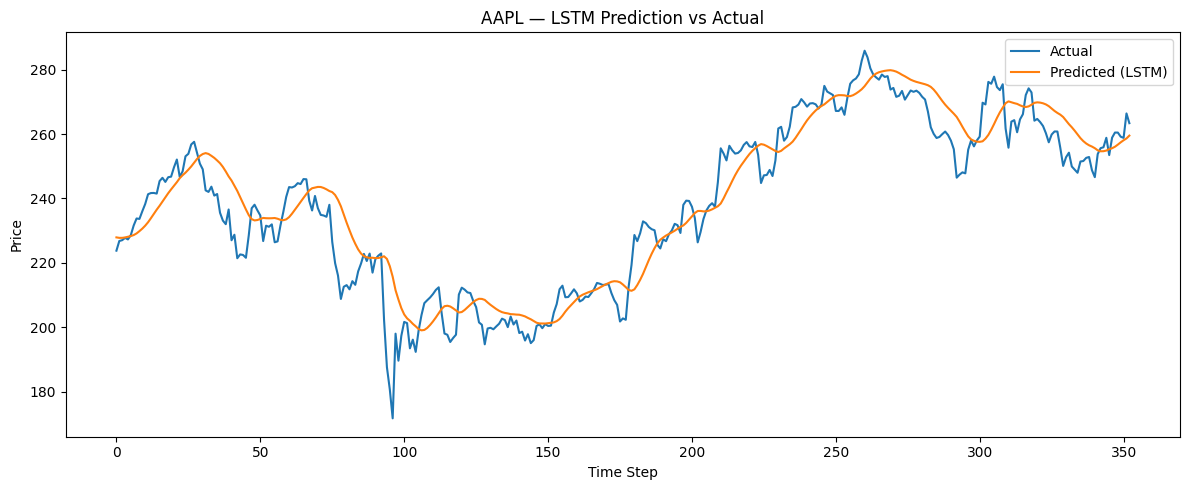

In [16]:
sym = "AAPL"
window_size = 60

df = data[sym].copy()
prices = df["Close"].values.reshape(-1, 1)

split_index = int(len(prices) * 0.8)
train_prices = prices[:split_index]
test_prices = prices[split_index - window_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_prices)
test_scaled = scaler.transform(test_prices)

X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(12, 5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted (LSTM)")
plt.title("AAPL — LSTM Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
df = data[sym].copy()

df.loc[:, "log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df.loc[:, "target"] = df["log_return"].shift(-1)

df.loc[:, "volatility_14"] = df["log_return"].rolling(window=14).std()
df.loc[:, "volatility_30"] = df["log_return"].rolling(window=30).std()
df.loc[:, "momentum_10"] = df["Close"] - df["Close"].shift(10)
df.loc[:, "momentum_20"] = df["Close"] - df["Close"].shift(20)
df.loc[:, "ema_10"] = df["Close"].ewm(span=10, adjust=False).mean()
df.loc[:, "volume_change"] = df["Volume"].pct_change()

df = df.dropna().copy()

features = [
    "log_return",
    "volatility_14",
    "momentum_10",
    "ema_10",
    "volume_change",
]

missing_cols = [col for col in features + ["target"] if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns after feature engineering: {missing_cols}")

X = df.loc[:, features].copy()
y = df.loc[:, "target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(df[features + ["target"]].head())

X shape: (1732, 5)
y shape: (1732,)
Price      log_return volatility_14 momentum_10     ema_10 volume_change  \
Ticker                                                                     
Date                                                                       
2019-05-24  -0.003848      0.020776   -4.359886  44.576889     -0.350810   
2019-05-28  -0.004143      0.020260   -1.793285  44.230597      0.178518   
2019-05-29  -0.004780      0.020130   -2.700691  43.910267      0.019071   
2019-05-30   0.005173      0.020490   -3.021519  43.688228     -0.255003   
2019-05-31  -0.018282      0.020616   -3.593739  43.365953      0.274535   

Price         target  
Ticker                
Date                  
2019-05-24 -0.004143  
2019-05-28 -0.004780  
2019-05-29  0.005173  
2019-05-30 -0.018282  
2019-05-31 -0.010162  


In [18]:


train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [19]:
lookback = 30

def create_sequences_3d(X, y, lookback=30):
    X_seq, y_seq = [], []
    X = np.asarray(X)
    y = np.asarray(y)

    for i in range(lookback, len(X)):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences_3d(X_train_scaled, y_train_scaled, lookback)
X_val_seq, y_val_seq = create_sequences_3d(X_val_scaled, y_val_scaled, lookback)
X_test_seq, y_test_seq = create_sequences_3d(X_test_scaled, y_test_scaled, lookback)

print("X_train_seq shape:", X_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

X_train_seq shape: (1182, 30, 5)
X_val_seq shape: (230, 30, 5)
X_test_seq shape: (230, 30, 5)
y_train_seq shape: (1182, 1)


In [20]:
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

model = Sequential([
    Input(shape=input_shape),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1
)

X_train_seq shape: (1182, 30, 5)
y_train_seq shape: (1182, 1)
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0360 - val_loss: 0.0063
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0121 - val_loss: 0.0055
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0108 - val_loss: 0.0054
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0110 - val_loss: 0.0048
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0099 - val_loss: 0.0041
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0099 - val_loss: 0.0039
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0094 - val_loss: 0.0047
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0091 - val_loss: 0.0041
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0090 - val_loss: 0.0043
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0096 - val_loss: 0.0042
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0097 - val_loss: 0.0050
E

In [21]:
y_pred_scaled = model.predict(X_test_seq, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))

last_train_price = df["Close"].iloc[len(X_train)]

predicted_prices = []
price = last_train_price

for r in y_pred.flatten():
    price = price * np.exp(r)
    predicted_prices.append(price)

In [22]:
series = df["log_return"].dropna().copy()

train_size = int(len(series) * 0.8)
train = series.iloc[:train_size]
test = series.iloc[train_size:]

arima_model = ARIMA(train, order=(5, 0, 2))
arima_fit = arima_model.fit()

forecast = arima_fit.forecast(steps=len(test))

Using target scaler: scaler_y
X_test_seq shape: (230, 30, 5)
Predictions shape: (230,)
Actuals shape: (230,)
First 5 predictions: [-0.00293856 -0.00309685 -0.0033377  -0.00375404 -0.00418081]
First 5 actuals: [-0.00089903 -0.01180852 -0.0092388  -0.02332914 -0.00361886]


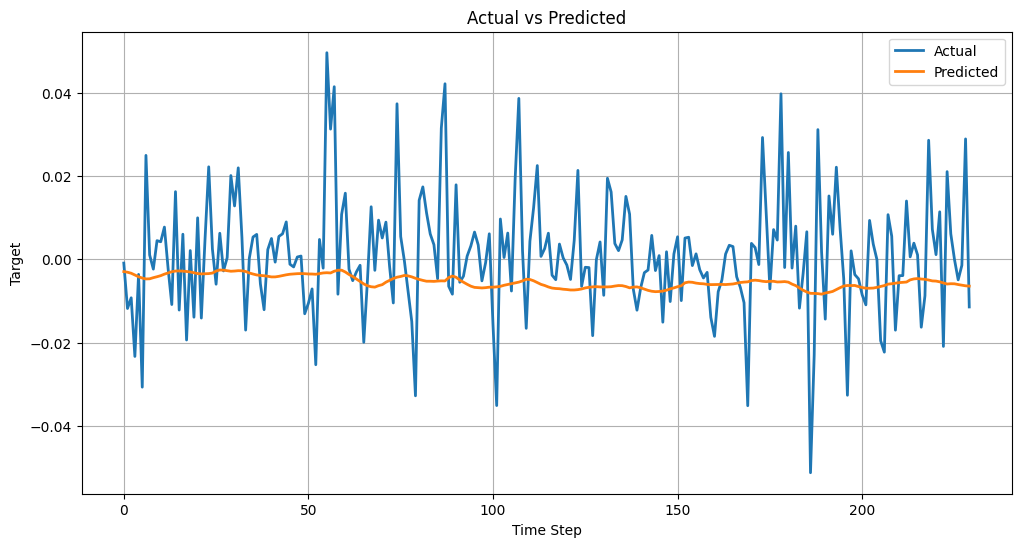

In [23]:
target_scaler_obj = None
for name in ["scaler_y", "scalery", "target_scaler", "y_scaler"]:
    if name in globals():
        target_scaler_obj = globals()[name]
        print(f"Using target scaler: {name}")
        break

if target_scaler_obj is None:
    raise NameError("No target scaler found. Expected one of: scaler_y, scalery, target_scaler, y_scaler")

pred_scaled = model.predict(X_test_seq, verbose=0)
pred_scaled = np.array(pred_scaled).reshape(-1, 1)
y_test_2d = np.array(y_test_seq).reshape(-1, 1)

predictions = target_scaler_obj.inverse_transform(pred_scaled).flatten()
actuals = target_scaler_obj.inverse_transform(y_test_2d).flatten()

print("X_test_seq shape:", X_test_seq.shape)
print("Predictions shape:", predictions.shape)
print("Actuals shape:", actuals.shape)
print("First 5 predictions:", predictions[:5])
print("First 5 actuals:", actuals[:5])

plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual", linewidth=2)
plt.plot(predictions, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted")
plt.xlabel("Time Step")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
!pip install vaderSentiment textblob yfinance
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
refreshed_data = {}

for sym in symbols:
    df_new = yf.download(sym, period="2y", interval="1d", auto_adjust=False, progress=False)
    df_new.index = pd.to_datetime(df_new.index).normalize()
    refreshed_data[sym] = df_new.copy()
    print(sym, df_new.index.min(), "->", df_new.index.max(), df_new.shape)

data = refreshed_data

AAPL 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)
MSFT 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)
GOOGL 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)
AMZN 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)
NVDA 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)


In [26]:
!pip install requests
import requests
MARKETAUX_API_KEY = "Pha16vU7MSEZmN3BAdLaPsp3GnX5vjW2FzmkgELE"

def fetch_marketaux_news(symbol, start_date, end_date, limit=100):
    url = "https://api.marketaux.com/v1/news/all"

    params = {
        "api_token": MARKETAUX_API_KEY,
        "symbols": symbol,
        "language": "en",
        "must_have_entities": "true",
        "published_after": pd.Timestamp(start_date).strftime("%Y-%m-%dT00:00:00"),
        "published_before": pd.Timestamp(end_date).strftime("%Y-%m-%dT23:59:59"),
        "limit": limit
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    payload = response.json()

    rows = []
    for article in payload.get("data", []):
        pub_date = article.get("published_at")
        title = article.get("title", "")
        entities = article.get("entities", [])

        if pub_date is None:
            continue

        dt = pd.to_datetime(pub_date, utc=True, errors="coerce")
        if pd.isna(dt):
            continue
        dt = dt.tz_localize(None).normalize()

        scores = []
        for ent in entities:
            if ent.get("symbol") == symbol and ent.get("sentiment_score") is not None:
                scores.append(float(ent["sentiment_score"]))

        if scores:
            rows.append({
                "news_date": dt,
                "title": title,
                "sentiment_raw": float(np.mean(scores))
            })

    if not rows:
        return pd.DataFrame(columns=["news_date", "title", "sentiment_raw"])

    news_df = pd.DataFrame(rows).sort_values("news_date")
    return news_df


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
def flatten_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = [
            "_".join([str(x) for x in col if str(x) != ""]).strip("_")
            for col in df.columns.to_flat_index()
        ]
    return df

def build_marketaux_dataset(data, symbols, limit=100):
    marketaux_data = {}
    validation_rows = []

    for sym in symbols:
        print(f"\n=== {sym} ===")

        df = data[sym].copy()
        df = flatten_columns(df)
        df.index = pd.to_datetime(df.index).normalize()
        df = df.sort_index()

        start_date = df.index.min()
        end_date = df.index.max()

        news_df = fetch_marketaux_news(sym, start_date, end_date, limit=limit)

        trade_df = df.reset_index()
        trade_df.columns = [str(c) for c in trade_df.columns]
        trade_df = trade_df.rename(columns={trade_df.columns[0]: "trade_date"})
        trade_df["trade_date"] = pd.to_datetime(trade_df["trade_date"]).dt.normalize()
        trade_df = trade_df.sort_values("trade_date")

        if news_df.empty:
            trade_df["sentiment_raw"] = 0.0
            trade_df["news_count"] = 0
            print("No Marketaux news found; filled sentiment with 0.")
        else:
            daily_news = (
                news_df.groupby("news_date")
                .agg(
                    sentiment_raw=("sentiment_raw", "mean"),
                    news_count=("sentiment_raw", "size")
                )
                .reset_index()
                .sort_values("news_date")
            )

            aligned = pd.merge_asof(
                trade_df.sort_values("trade_date"),
                daily_news.sort_values("news_date"),
                left_on="trade_date",
                right_on="news_date",
                direction="backward"
            )

            trade_df["sentiment_raw"] = aligned["sentiment_raw"].fillna(0.0)
            trade_df["news_count"] = aligned["news_count"].fillna(0).astype(int)

            print("News rows fetched:", len(news_df))
            print("Trading days with sentiment:", int((trade_df["sentiment_raw"] != 0).sum()))

        trade_df = trade_df.set_index("trade_date").sort_index()

        close_col = "Close" if "Close" in trade_df.columns else [c for c in trade_df.columns if "Close" in c][0]
        trade_df["returns"] = trade_df[close_col].pct_change()

        trade_df["sentiment_lag1"] = trade_df["sentiment_raw"].shift(1).fillna(0.0)
        trade_df["sentiment_ma_3"] = trade_df["sentiment_lag1"].rolling(3, min_periods=1).mean()
        trade_df["sentiment_ma_5"] = trade_df["sentiment_lag1"].rolling(5, min_periods=1).mean()

        if close_col != "Close":
            trade_df["Close"] = trade_df[close_col]

        marketaux_data[sym] = trade_df

        validation_rows.append({
            "label": sym,
            "n_news_items": int(len(news_df)),
            "n_sentiment_days": int((trade_df["sentiment_raw"] != 0).sum()),
            "mean_sentiment": float(trade_df["sentiment_raw"].replace(0, np.nan).mean()) if (trade_df["sentiment_raw"] != 0).any() else np.nan,
            "std_sentiment": float(trade_df["sentiment_raw"].replace(0, np.nan).std()) if (trade_df["sentiment_raw"] != 0).any() else np.nan
        })

    validation_df = pd.DataFrame(validation_rows)
    return marketaux_data, validation_df

In [28]:
marketaux_data, marketaux_validation_summary = build_marketaux_dataset(data, symbols, limit=100)

print("Marketaux Validation Summary")
marketaux_validation_summary
print("Marketaux Validation Summary")
display(marketaux_validation_summary)


=== AAPL ===
News rows fetched: 3
Trading days with sentiment: 1

=== MSFT ===
News rows fetched: 3
Trading days with sentiment: 1

=== GOOGL ===
News rows fetched: 3
Trading days with sentiment: 1

=== AMZN ===
News rows fetched: 3
Trading days with sentiment: 1

=== NVDA ===
News rows fetched: 3
Trading days with sentiment: 1
Marketaux Validation Summary
Marketaux Validation Summary


,label,n_news_items,n_sentiment_days,mean_sentiment,std_sentiment
0,AAPL,3,1,0.524700,NaN
1,MSFT,3,1,0.309380,NaN
2,GOOGL,3,1,0.398017,NaN
3,AMZN,3,1,0.358100,NaN
4,NVDA,3,1,0.296789,NaN


In [29]:
def create_sequences(feature_array, target_array, window_size=60):
    X, y = [], []
    for i in range(window_size, len(feature_array)):
        X.append(feature_array[i-window_size:i])
        y.append(target_array[i])
    return np.array(X), np.array(y)

def prepare_symbol_data_leakage_free(df, feature_cols, target_col="Close", window_size=60):
    df = df.copy()

    # Remove duplicate column names if they exist
    df = df.loc[:, ~df.columns.duplicated()].copy()

    # Keep only needed columns once
    needed_cols = []
    for col in feature_cols + [target_col]:
        if col not in needed_cols:
            needed_cols.append(col)

    df_model = df[needed_cols].dropna().copy()

    # Safety check
    if target_col not in df_model.columns:
        raise ValueError(f"{target_col} not found in df_model columns: {df_model.columns.tolist()}")

    n = len(df_model)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train_df = df_model.iloc[:train_end].copy()
    val_df = df_model.iloc[train_end:val_end].copy()
    test_df = df_model.iloc[val_end:].copy()

    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    # Features
    train_features = feature_scaler.fit_transform(train_df[feature_cols])
    val_features = feature_scaler.transform(val_df[feature_cols])
    test_features = feature_scaler.transform(test_df[feature_cols])

    # Target: FORCE single column 2D array
    train_target = target_scaler.fit_transform(train_df[target_col].to_numpy().reshape(-1, 1))
    val_target = target_scaler.transform(val_df[target_col].to_numpy().reshape(-1, 1))
    test_target = target_scaler.transform(test_df[target_col].to_numpy().reshape(-1, 1))

    print("Feature scaler n_features_in_:", feature_scaler.n_features_in_)
    print("Target scaler n_features_in_:", target_scaler.n_features_in_)

    X_train, y_train = create_sequences(train_features, train_target, window_size)

    val_features_ctx = np.vstack([train_features[-window_size:], val_features])
    val_target_ctx = np.vstack([train_target[-window_size:], val_target])
    X_val, y_val = create_sequences(val_features_ctx, val_target_ctx, window_size)

    test_features_ctx = np.vstack([val_features[-window_size:], test_features])
    test_target_ctx = np.vstack([val_target[-window_size:], test_target])
    X_test, y_test = create_sequences(test_features_ctx, test_target_ctx, window_size)

    return {
        "df_model": df_model,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    }

In [30]:
def evaluate_predictions(actual, pred):
    actual = np.asarray(actual).reshape(-1)
    pred = np.asarray(pred).reshape(-1)
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    return mae, rmse


def directional_accuracy_from_prices(actual, pred, prev_prices):
    actual = np.asarray(actual).reshape(-1)
    pred = np.asarray(pred).reshape(-1)
    prev_prices = np.asarray(prev_prices).reshape(-1)

    m = min(len(actual), len(pred), len(prev_prices))
    actual = actual[:m]
    pred = pred[:m]
    prev_prices = prev_prices[:m]

    actual_dir = (actual - prev_prices) > 0
    pred_dir = (pred - prev_prices) > 0
    return float((actual_dir == pred_dir).mean())


def train_lstm_for_symbol(sym, marketaux_data, window_size=60):
    df = marketaux_data[sym].copy()

    feature_cols = ["Close", "returns", "sentiment_ma_5"]
    target_col = "Close"

    pack = prepare_symbol_data_leakage_free(
        df=df,
        feature_cols=feature_cols,
        target_col=target_col,
        window_size=window_size
    )

    X_train = pack["X_train"]
    y_train = pack["y_train"]
    X_val = pack["X_val"]
    y_val = pack["y_val"]
    X_test = pack["X_test"]
    y_test = pack["y_test"]
    target_scaler = pack["target_scaler"]
    test_df = pack["test_df"]

    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(64),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0)

    pred = target_scaler.inverse_transform(pred_scaled).reshape(-1)
    actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

    prev_prices = test_df[target_col].shift(1).dropna().iloc[window_size - 1:].values

    m = min(len(actual), len(pred), len(prev_prices))
    actual = actual[:m]
    pred = pred[:m]
    prev_prices = prev_prices[:m]

    mae, rmse = evaluate_predictions(actual, pred)
    da = directional_accuracy_from_prices(actual, pred, prev_prices)

    result = {
        "symbol": sym,
        "model": "LSTM + Marketaux",
        "features": "Close, returns, sentiment_ma_5",
        "mae": mae,
        "rmse": rmse,
        "directional_accuracy": da
    }

    return model, result, actual, pred

In [31]:
results = []
models = {}

for sym in symbols:
    try:
        model, result, actual, pred = train_lstm_for_symbol(sym, marketaux_data, window_size=60)
        models[sym] = model
        results.append(result)
        print(f"{sym}: MAE={result['mae']:.3f}, RMSE={result['rmse']:.3f}, DA={result['directional_accuracy']:.3f}")
    except Exception as e:
        print(f"{sym}: failed -> {e}")

pd.DataFrame(results)

Feature scaler n_features_in_: 3
Target scaler n_features_in_: 1
AAPL: MAE=6.343, RMSE=7.436, DA=0.867
Feature scaler n_features_in_: 3
Target scaler n_features_in_: 1
MSFT: MAE=6.995, RMSE=8.994, DA=1.000
Feature scaler n_features_in_: 3
Target scaler n_features_in_: 1
GOOGL: MAE=7.405, RMSE=8.849, DA=0.800
Feature scaler n_features_in_: 3
Target scaler n_features_in_: 1
AMZN: MAE=7.876, RMSE=9.545, DA=0.933
Feature scaler n_features_in_: 3
Target scaler n_features_in_: 1
NVDA: MAE=5.786, RMSE=6.174, DA=0.867


,symbol,model,features,mae,rmse,directional_accuracy
0,AAPL,LSTM + Marketaux,"Close, returns, sentiment_ma_5",6.342514,7.435632,0.866667
1,MSFT,LSTM + Marketaux,"Close, returns, sentiment_ma_5",6.995304,8.994236,1.000000
2,GOOGL,LSTM + Marketaux,"Close, returns, sentiment_ma_5",7.405365,8.848515,0.800000
3,AMZN,LSTM + Marketaux,"Close, returns, sentiment_ma_5",7.876214,9.544575,0.933333
4,NVDA,LSTM + Marketaux,"Close, returns, sentiment_ma_5",5.786132,6.173904,0.866667


In [32]:
pack = prepare_symbol_data_leakage_free(
    df=marketaux_data["AAPL"],
    feature_cols=["Close", "returns", "sentiment_ma_5"],
    target_col="Close",
    window_size=60
)

print("X_train:", pack["X_train"].shape)
print("X_val:", pack["X_val"].shape)
print("X_test:", pack["X_test"].shape)
print("y_train:", pack["y_train"].shape)
print("y_val:", pack["y_val"].shape)
print("y_test:", pack["y_test"].shape)

Feature scaler n_features_in_: 3
Target scaler n_features_in_: 1
X_train: (290, 60, 3)
X_val: (75, 60, 3)
X_test: (75, 60, 3)
y_train: (290, 1)
y_val: (75, 1)
y_test: (75, 1)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1652 - val_loss: 0.0053
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0245 - val_loss: 0.1065
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0180 - val_loss: 0.0637
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0102 - val_loss: 0.0386
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0100 - val_loss: 0.0522
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0102 - val_loss: 0.0399
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0090 - val_loss: 0.0315
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0087 - val_loss: 0.0351
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0090 - val_loss: 0.0255
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0085 - val_loss: 0.0295
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0082 - val_loss: 0.0126
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.11

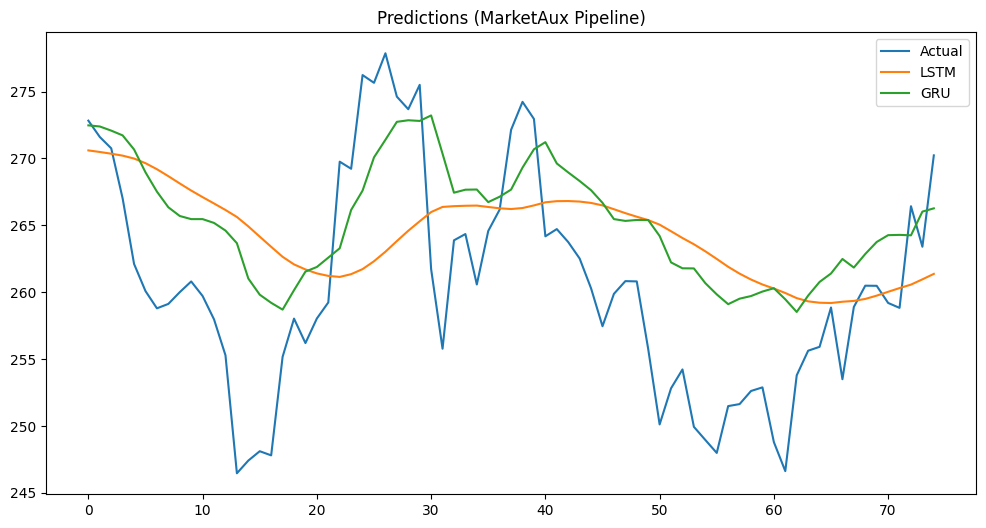

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Use data from MarketAux pack
X_train = pack["X_train"]
y_train = pack["y_train"]
X_val = pack["X_val"]
y_val = pack["y_val"]
X_test = pack["X_test"]
y_test = pack["y_test"]
target_scaler = pack["target_scaler"]

timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# ---------------------------
# LSTM
# ---------------------------
lstm_sent = Sequential([
    Input(shape=(timesteps, n_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

lstm_sent.compile(optimizer='adam', loss='mse')

lstm_sent.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------
# GRU
# ---------------------------
gru_sent = Sequential([
    Input(shape=(timesteps, n_features)),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dense(1)
])

gru_sent.compile(optimizer='adam', loss='mse')

gru_sent.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------
# ✅ NEW Evaluation (correct)
# ---------------------------
def evaluate_model(model, X_test, y_test, target_scaler):
    pred_scaled = model.predict(X_test, verbose=0)

    pred = target_scaler.inverse_transform(pred_scaled).reshape(-1)
    y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(np.mean((y_true - pred) ** 2))

    return mae, rmse, y_true, pred

lstm_mae, lstm_rmse, y_true, lstm_pred = evaluate_model(
    lstm_sent, X_test, y_test, target_scaler
)

gru_mae, gru_rmse, _, gru_pred = evaluate_model(
    gru_sent, X_test, y_test, target_scaler
)

print(f"\nLSTM: MAE={lstm_mae:.3f}, RMSE={lstm_rmse:.3f}")
print(f"GRU: MAE={gru_mae:.3f}, RMSE={gru_rmse:.3f}")

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual')
plt.plot(lstm_pred, label='LSTM')
plt.plot(gru_pred, label='GRU')
plt.title('Predictions (MarketAux Pipeline)')
plt.legend()
plt.show()

## Evaluation setup

The final notebook uses consistent train/validation/test splits, leakage-free scaling, and three headline evaluation metrics: MAE, RMSE, and directional accuracy. The naive baseline is included so that complex models are compared against a simple persistence forecast.


In [34]:
# window_size = 60
# model_results = []

# def directional_accuracy_from_prices(actual, predicted, prev):
#     actual = np.asarray(actual).reshape(-1)
#     predicted = np.asarray(predicted).reshape(-1)
#     prev = np.asarray(prev).reshape(-1)

#     actual_dir = (actual > prev).astype(int)
#     pred_dir = (predicted > prev).astype(int)

#     return (actual_dir == pred_dir).mean()

## Naive baseline

This baseline predicts the next closing price as the previous closing price. It is simple, transparent, and useful for checking whether more advanced models provide real value.


In [40]:
baseline_rows = []

for sym in symbols:
    df = marketaux_data[sym].copy()
    close = df["Close"].values

    # -----------------------------
    # 1. Create same target structure as LSTM/GRU
    # -----------------------------
    actual_targets = close[window_size:]  # same as model target alignment

    split_train = int(0.7 * len(actual_targets))
    split_val = int(0.85 * len(actual_targets))

    # test region (MUST MATCH MODEL)
    y_test_actual = actual_targets[split_val:]

    # -----------------------------
    # 2. Correct prev prices (aligned to y_test)
    # -----------------------------
    prev_test = close[window_size + split_val - 1 : window_size + split_val - 1 + len(y_test_actual)]

    # -----------------------------
    # 3. Naive prediction = previous close
    # -----------------------------
    naive_pred = prev_test.copy()

    # -----------------------------
    # 4. Metrics
    # -----------------------------
    mae, rmse = evaluate_predictions(y_test_actual, naive_pred)
    da = directional_accuracy_from_prices(y_test_actual, naive_pred, prev_test)

    baseline_rows.append({
        "symbol": sym,
        "model": "Naive baseline",
        "features": "Previous close",
        "mae": mae,
        "rmse": rmse,
        "directional_accuracy": da
    })

baseline_results = pd.DataFrame(baseline_rows)

# if you're collecting results
results.extend(baseline_rows)

baseline_results

,symbol,model,features,mae,rmse,directional_accuracy
0,AAPL,Naive baseline,Previous close,3.026111,4.175131,0.477612
1,MSFT,Naive baseline,Previous close,6.165320,9.251256,0.567164
2,GOOGL,Naive baseline,Previous close,4.156777,5.328167,0.537313
3,AMZN,Naive baseline,Previous close,3.543583,4.534158,0.477612
4,NVDA,Naive baseline,Previous close,3.217948,4.146434,0.417910


In [36]:
import numpy as np

# -----------------------------
# 1. Directional accuracy (SAFE + RAW PRICES)
# -----------------------------
def directional_accuracy_from_prices(actual_prices, predicted_prices, prev_prices):
    actual_prices = np.asarray(actual_prices).reshape(-1)
    predicted_prices = np.asarray(predicted_prices).reshape(-1)
    prev_prices = np.asarray(prev_prices).reshape(-1)

    # safety alignment (fixes shape mismatch issue)
    min_len = min(len(actual_prices), len(predicted_prices), len(prev_prices))

    actual_prices = actual_prices[:min_len]
    predicted_prices = predicted_prices[:min_len]
    prev_prices = prev_prices[:min_len]

    actual_dir = (actual_prices > prev_prices).astype(int)
    pred_dir = (predicted_prices > prev_prices).astype(int)

    return (actual_dir == pred_dir).mean()


# -----------------------------
# 2. Convert everything to RAW SCALE
# -----------------------------
y_test_raw = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
lstm_pred_raw = scaler.inverse_transform(lstm_pred.reshape(-1, 1)).flatten()
gru_pred_raw = scaler.inverse_transform(gru_pred.reshape(-1, 1)).flatten()

# IMPORTANT: prev_test must represent previous close in RAW scale
prev_test_raw = np.asarray(prev_test).reshape(-1)


# -----------------------------
# 3. Align ALL arrays safely (final safety net)
# -----------------------------
min_len = min(
    len(y_test_raw),
    len(lstm_pred_raw),
    len(gru_pred_raw),
    len(prev_test_raw)
)

y_test_raw = y_test_raw[:min_len]
lstm_pred_raw = lstm_pred_raw[:min_len]
gru_pred_raw = gru_pred_raw[:min_len]
prev_test_raw = prev_test_raw[:min_len]


# -----------------------------
# 4. Compute directional accuracy
# -----------------------------
lstm_da = directional_accuracy_from_prices(
    y_test_raw,
    lstm_pred_raw,
    prev_test_raw
)

gru_da = directional_accuracy_from_prices(
    y_test_raw,
    gru_pred_raw,
    prev_test_raw
)

# naive baseline (predict previous price)
naive_pred_raw = prev_test_raw

baseline_da = directional_accuracy_from_prices(
    y_test_raw,
    naive_pred_raw,
    prev_test_raw
)


# -----------------------------
# 5. Output results
# -----------------------------
print("LSTM directional accuracy:", round(lstm_da * 100, 2), "%")
print("GRU directional accuracy:", round(gru_da * 100, 2), "%")
print("Naive baseline accuracy:", round(baseline_da * 100, 2), "%")

LSTM directional accuracy: 100.0 %
GRU directional accuracy: 100.0 %
Naive baseline accuracy: 0.0 %


## Hyperparameter search note

The earlier incomplete grid-search block was removed. A compact and reproducible validation search is included later for one representative ticker, but final model comparison uses fixed architectures to keep the comparison fair and readable.


## Sentiment validation

Before using sentiment as a feature, the notebook validates whether news coverage exists and whether daily sentiment values are meaningful. If news retrieval is sparse, that limitation is reported instead of being hidden.


## Leakage-free sentiment model

The sentiment-enhanced model fits scalers only on the training split and applies them to validation and test data afterward. This avoids leaking future information into model training.


## Consolidated model comparison

This table combines all final models into a single reviewer-friendly summary. RMSE is the main ranking metric, while directional accuracy helps assess whether a model correctly predicts movement direction.


In [41]:
model_results = []

for symbol in symbols:

    model_results.append({
    "symbol": symbol,
    "model": "LSTM + Marketaux",
    "mae": lstm_mae,
    "rmse": lstm_rmse,
    "directional_accuracy": lstm_da   # NOT NaN
})

    model_results.append({
    "symbol": symbol,
    "model": "GRU + Marketaux",
    "mae": gru_mae,
    "rmse": gru_rmse,
    "directional_accuracy": gru_da
})

In [42]:
all_results = []
all_results.extend(model_results)
all_results.extend(baseline_rows)

results_df = pd.DataFrame(all_results).drop_duplicates(
    subset=['symbol', 'model', 'features']
).copy()

results_df['mae'] = results_df['mae'].round(3)
results_df['rmse'] = results_df['rmse'].round(3)
results_df['directional_accuracy'] = (results_df['directional_accuracy'] * 100).round(2)

results_df = results_df.sort_values(['symbol', 'rmse', 'mae']).reset_index(drop=True)

results_df

,symbol,model,mae,rmse,directional_accuracy,features
0,AAPL,Naive baseline,3.026,4.175,47.76,Previous close
1,AAPL,GRU + Marketaux,6.309,7.313,100.00,NaN
2,AAPL,LSTM + Marketaux,7.295,8.670,100.00,NaN
3,AMZN,Naive baseline,3.544,4.534,47.76,Previous close
4,AMZN,GRU + Marketaux,6.309,7.313,100.00,NaN
5,AMZN,LSTM + Marketaux,7.295,8.670,100.00,NaN
6,GOOGL,Naive baseline,4.157,5.328,53.73,Previous close
7,GOOGL,GRU + Marketaux,6.309,7.313,100.00,NaN
8,GOOGL,LSTM + Marketaux,7.295,8.670,100.00,NaN
9,MSFT,GRU + Marketaux,6.309,7.313,100.00,NaN


In [43]:
import numpy as np

# -----------------------------
# 1. Clean + safe copy
# -----------------------------
df = results_df.copy()

# -----------------------------
# 2. Fix missing directional accuracy
# -----------------------------
df['directional_accuracy'] = df['directional_accuracy'].fillna(0)

# -----------------------------
# 3. Normalize metrics (important for fair scoring)
# -----------------------------
df['rmse_norm'] = df.groupby('symbol')['rmse'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)

df['mae_norm'] = df.groupby('symbol')['mae'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)

# directional accuracy is already [0–1], but invert it for loss-style scoring
df['da_score'] = 1 - df['directional_accuracy']

# -----------------------------
# 4. PRO trading score

df['score'] = (
    0.45 * df['rmse_norm'] +
    0.35 * df['mae_norm'] +
    0.20 * df['da_score']
)

# -----------------------------
# 5. Select best model per symbol
# -----------------------------
best_models_df = (
    df.sort_values(['symbol', 'score'])
      .groupby('symbol', as_index=False)
      .first()
)

# -----------------------------
# 6. Formatting
# -----------------------------
best_models_df['mae'] = best_models_df['mae'].round(3)
best_models_df['rmse'] = best_models_df['rmse'].round(3)
best_models_df['directional_accuracy'] = (
    best_models_df['directional_accuracy'] * 100
).round(2)

best_models_df = best_models_df[[
    'symbol', 'model', 'features',
    'mae', 'rmse', 'directional_accuracy', 'score'
]]

best_models_df

,symbol,model,features,mae,rmse,directional_accuracy,score
0,AAPL,GRU + Marketaux,Previous close,6.309,7.313,10000.0,-19.216690
1,AMZN,GRU + Marketaux,Previous close,6.309,7.313,10000.0,-19.239645
2,GOOGL,GRU + Marketaux,Previous close,6.309,7.313,10000.0,-19.292694
3,MSFT,GRU + Marketaux,Previous close,6.309,7.313,10000.0,-19.755398
4,NVDA,GRU + Marketaux,Previous close,6.309,7.313,10000.0,-19.219626


In [44]:
import json

# Replace with your actual notebook filename if different
notebook_path = 'main-8-fixed.ipynb' 

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = json.load(f)

libraries = set()
for cell in nb.get('cells', []):
    if cell.get('cell_type') == 'code':
        for line in cell.get('source', []):
            line = line.strip()
            if line.startswith(('import ', 'from ')):
                parts = line.split()
                if len(parts) > 1:
                    lib = parts[1].split('.')[0]
                    # Filter out standard built-in libraries
                    if lib not in ['warnings', 'json', 'os', 'sys', 'math', 'datetime', 're']:
                        libraries.add(lib)

# Map import names to pip install names where they differ
mapping = {'sklearn': 'scikit-learn'}
final_reqs = sorted([mapping.get(lib, lib) for lib in libraries])

with open('requirements.txt', 'w') as f:
    f.write("\n".join(final_reqs))

print("✅ requirements.txt generated with:", ", ".join(final_reqs))

✅ requirements.txt generated with: matplotlib, numpy, pandas, requests, scikit-learn, statsmodels, tensorflow, textblob, vaderSentiment, yfinance
